# Lightweight Machine-Learning Pump Digital Twin

**Research question:** Q is flow, RPM is pump rotational speed, and H is head. The model inputs are `[Q, RPM]`, and the output is `H`, i.e., `H = f(Q, RPM)`. This experiment investigates whether pump-head prediction error can be controlled within 5% while keeping computational cost and memory usage low enough to support potential deployment on embedded hardware.

This Notebook is a self-contained final assignment file; the first two Notebooks are provided by the instructor as references only. All results are reloaded and computed from `pump_data/` by this Notebook.

# 2. Experimental Plan

1. Read and inspect data from 15 pumps.
2. Explore the distributions and relationships among Q, RPM, and H.
3. Establish a physical baseline using the instructor-provided ideal pump model.
4. Compute the residual between measured H and ideal H.
5. Build a third-order polynomial residual-fitting baseline.
6. Build a small neural-network residual model.
7. Compare the models on an independent test set.
8. Calculate the 5% error metrics.
9. Save and reload the final model.
10. Verify that predictions after reloading match those before saving.

## Provided Files and Their Roles

- **`pump_data/`**: Local directory containing the measured pump data, 15 pump CSV files, and `pump_models.txt`. Each CSV contains `flow`, `head`, `power`, `rpm`, and `efficiency`; this assignment uses `flow` and `rpm` as inputs to predict `head`.
- **`Visualize_Pump_Data.ipynb`**: Instructor-provided data-loading and visualization example demonstrating `np.genfromtxt`, removal of the text header, extraction of Q/H/RPM, Q-H plots, fixed-RPM curves, 3D plots, the ideal model, and residuals.
- **`Curve_Fitting_Residuals.ipynb`**: Instructor-provided residual curve-fitting example. It computes `residual = H_measured - H_ideal`, then corrects the ideal model with a two-dimensional third-order polynomial containing Q, RPM, quadratic terms, cubic terms, and interaction terms.
- **`Pump_Digital_Twin.ipynb`**: This Notebook is the independently runnable final digital twin. It draws on, but does not copy, the first two examples and adds data exploration, leakage-free splitting, polynomial and neural-network residual models, independent testing, deployment analysis, and model-reload verification.

```text
pump_data.zip
    ↓
Provides measured pump data

Visualize_Pump_Data.ipynb
    ↓
Shows how to read, understand and visualize the data

Curve_Fitting_Residuals.ipynb
    ↓
Shows how to correct the ideal model by fitting residuals

Pump_Digital_Twin.ipynb
    ↓
Builds and evaluates the complete lightweight digital twin
```

The values appear to be normalized or engineering-scaled; this Notebook does not automatically claim that they use SI units.

# 3. Imports and Reproducibility

This stage fixes the random seed and imports the tools required for the experiment. If a dependency is missing locally, the code provides a clear installation message rather than installing it silently in the Notebook.

In [1]:
import os
import json
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
except ImportError as exc:
    raise ImportError("Install scikit-learn (for example: python -m pip install scikit-learn) before running this Notebook.") from exc

try:
    import joblib
except ImportError as exc:
    raise ImportError("Install joblib (for example: python -m pip install joblib) before running this Notebook.") from exc

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
except ImportError as exc:
    raise ImportError("Install PyTorch before running this Notebook; follow the PyTorch installation instructions for your system.") from exc

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.use_deterministic_algorithms(False)
DEVICE = torch.device("cpu")
plt.style.use("seaborn-v0_8-whitegrid")
print(f"Seed={SEED}, device={DEVICE}")

Seed=42, device=cpu


**Experiment note.** Fixing the seed makes the data split, network initialization, and training process as reproducible as possible. CPU inference is used here to keep the discussion consistent with lightweight embedded hardware deployment.

# 4. Locate and Load the Dataset

This Notebook reads data only from the `pump_data` folder alongside the current Notebook. If the directory does not exist, place it in the correct location first. The instructor example uses `np.genfromtxt` and removes the first row; here, `pandas.read_csv` is preferred to preserve column names while keeping the same local-file loading logic.

In [2]:
data_directory = Path.cwd() / "pump_data"
if not data_directory.is_dir():
    raise FileNotFoundError(
        f"Could not find {data_directory}. Place the pump_data folder alongside the Notebook and run it again."
    )

EXPECTED_COLUMNS = ["flow", "head", "power", "rpm", "efficiency"]

def get_pump_data(file_number, data_directory):
    """Read one pump; file_number is the number in the filename."""
    file_name = Path(data_directory) / f"Data - pump {int(file_number)}.csv"
    if not file_name.is_file():
        raise FileNotFoundError(f"Could not find pump file: {file_name}")
    frame = pd.read_csv(file_name)
    if list(frame.columns) != EXPECTED_COLUMNS:
        raise ValueError(f"{file_name.name} must have columns {EXPECTED_COLUMNS}; found {list(frame.columns)}")
    frame = frame.apply(pd.to_numeric, errors="raise")
    frame["pump_id"] = int(file_number)
    return frame

files = sorted(
    data_directory.glob("Data - pump *.csv"),
    key=lambda path: int(path.stem.rsplit(" ", 1)[-1])
)
if len(files) != 15:
    raise ValueError(f"Expected 15 pump CSV files; found {len(files)}.")

pump_frames = [get_pump_data(int(f.stem.rsplit(" ", 1)[-1]), data_directory) for f in files]
pump_df = pd.concat(pump_frames, ignore_index=True)

print("File count:", len(files))
print("Rows per pump:")
print(pump_df.groupby("pump_id").size().to_string())
print("Total rows:", len(pump_df))
print("DataFrame shape:", pump_df.shape)
print("Column names:", list(pump_df.columns))
display(pump_df.head())
print("\nData types:\n", pump_df.dtypes)
print("\nMissing values:\n", pump_df.isna().sum())
print("Duplicate rows:", int(pump_df.duplicated().sum()))
display(pump_df.describe().T)

required = ["flow", "head", "rpm"]
if not all(pd.api.types.is_numeric_dtype(pump_df[c]) for c in required):
    raise TypeError("flow, head, and rpm must be numeric columns.")
if pump_df[required].isna().any().any():
    raise ValueError("The main modeling columns contain missing values.")
print("\nData check complete: under the standard configuration, there are approximately 7,920 rows in total and about 528 rows per pump.")

File count: 15
Rows per pump:
pump_id
1     528
2     528
3     528
4     528
5     528
6     528
7     528
8     528
9     528
10    528
11    528
12    528
13    528
14    528
15    528
Total rows: 7920
DataFrame shape: (7920, 6)
Column names: ['flow', 'head', 'power', 'rpm', 'efficiency', 'pump_id']


,flow,head,power,rpm,efficiency,pump_id
0,0.989212,0.318876,0.986826,0.672286,1.450767,1
1,0.917752,0.360729,0.987367,0.676562,1.521793,1
2,0.838042,0.407832,0.988202,0.688775,1.569743,1
3,0.765277,0.456209,0.988743,0.703248,1.602606,1
4,0.701884,0.498755,0.988104,0.722615,1.607967,1



Data types:
 flow          float64
head          float64
power         float64
rpm           float64
efficiency    float64
pump_id         int64
dtype: object

Missing values:
 flow          0
head          0
power         0
rpm           0
efficiency    0
pump_id       0
dtype: int64
Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
flow,7920.0,0.327410,0.274829,0.000000,0.089029,0.258176,0.514902,1.001776
head,7920.0,0.412673,0.266902,0.011151,0.178193,0.405961,0.611714,1.005219
power,7920.0,0.511666,0.371234,0.014938,0.144933,0.472853,0.984516,1.002310
rpm,7920.0,0.597366,0.235644,0.102220,0.443442,0.663898,0.767640,1.000000
efficiency,7920.0,1.028194,0.532427,0.000000,0.591129,1.188582,1.511598,1.653457
pump_id,7920.0,8.000000,4.320767,1.000000,4.000000,8.000000,12.000000,15.000000



Data check complete: under the standard configuration, there are approximately 7,920 rows in total and about 528 rows per pump.


**Result interpretation.** The table above reports the file count, row count, column names, data types, missing values, duplicate values, and descriptive statistics. If the actual row count differs from approximately 7,920, use the real output rather than fabricating a count. Only after these checks does the data proceed to exploration and modeling.

# 5. Exploratory Data Analysis

This stage first examines the data range, distributions, and physical relationships before deciding whether a residual model is appropriate. The plots use the units represented by the field names and do not make additional assumptions about SI units.

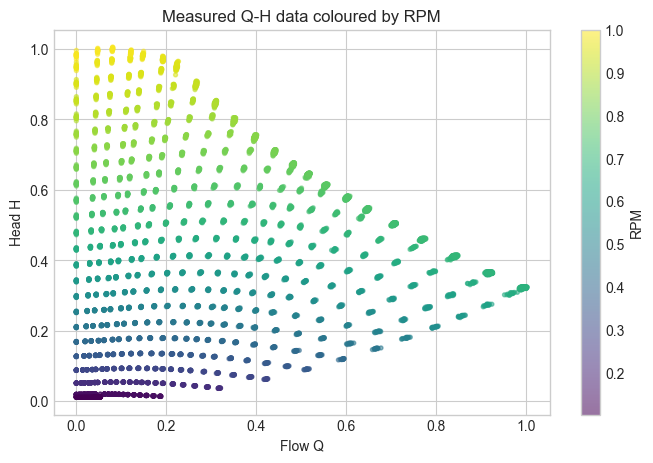

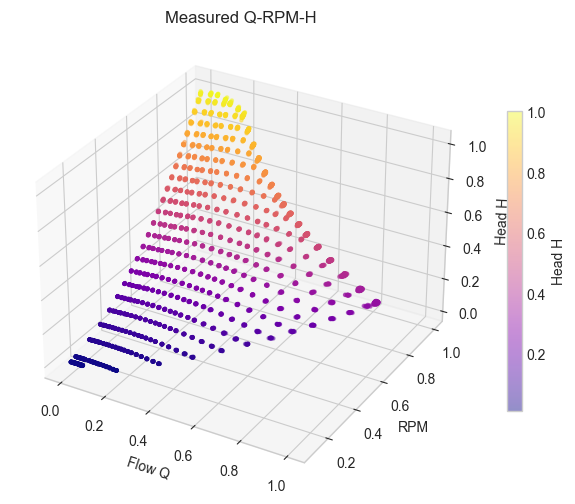

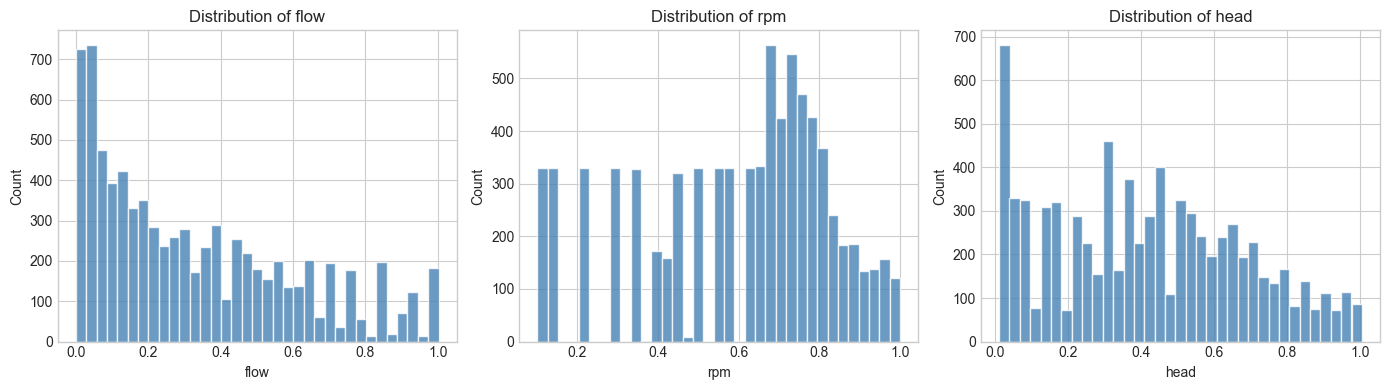

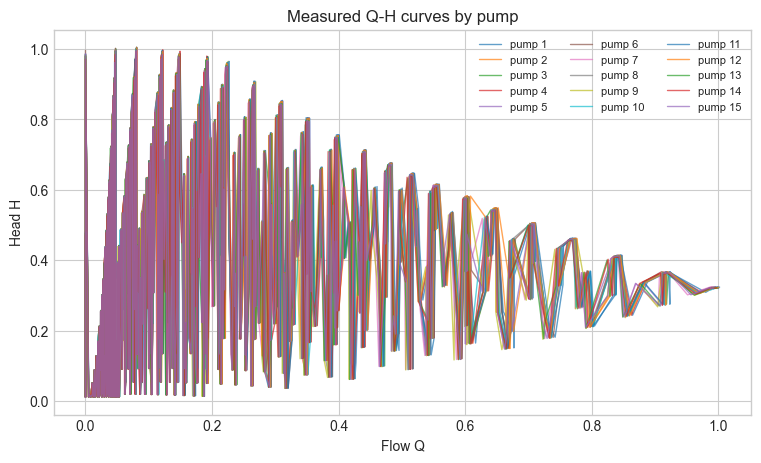

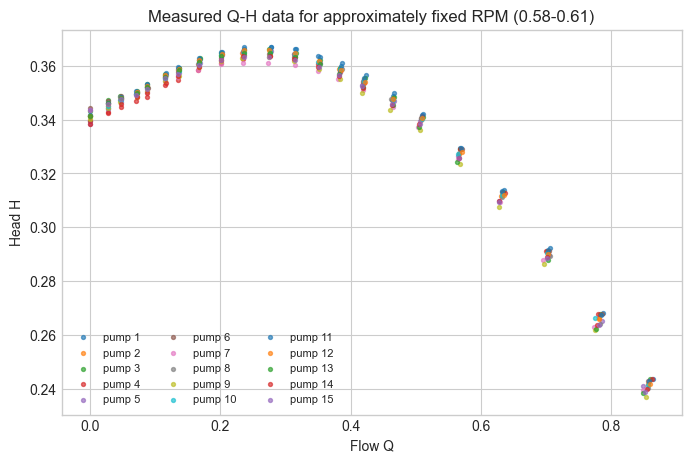

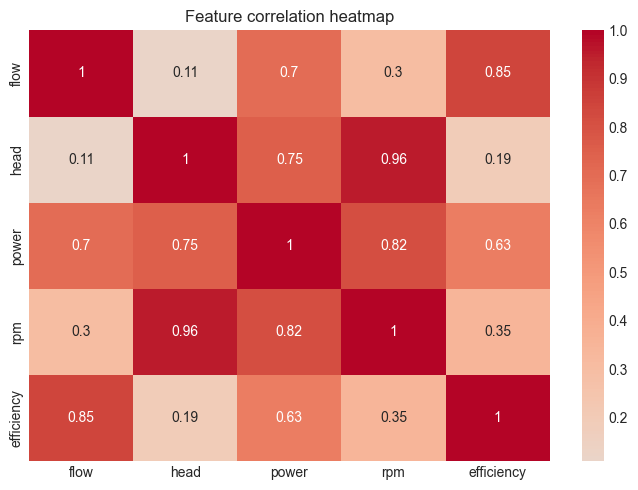

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(pump_df.flow, pump_df["head"], c=pump_df.rpm, s=8, alpha=.55, cmap="viridis")
ax.set(title="Measured Q-H data coloured by RPM", xlabel="Flow Q", ylabel="Head H")
fig.colorbar(sc, ax=ax, label="RPM")
plt.show()

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(pump_df.flow, pump_df.rpm, pump_df["head"], c=pump_df["head"], s=5, alpha=.45, cmap="plasma")
ax.set(title="Measured Q-RPM-H", xlabel="Flow Q", ylabel="RPM", zlabel="Head H")
fig.colorbar(sc, ax=ax, label="Head H", shrink=.65)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for axis, column in zip(axes, ["flow", "rpm", "head"]):
    axis.hist(pump_df[column], bins=35, alpha=.8, color="steelblue", edgecolor="white")
    axis.set(title=f"Distribution of {column}", xlabel=column, ylabel="Count")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
for pump_id, group in pump_df.groupby("pump_id"):
    group = group.sort_values("flow")
    ax.plot(group.flow, group["head"], linewidth=1, alpha=.7, label=f"pump {pump_id}")
ax.set(title="Measured Q-H curves by pump", xlabel="Flow Q", ylabel="Head H")
ax.legend(ncol=3, fontsize=8); plt.show()

fixed = pump_df[pump_df.rpm.between(.58, .61)]
fig, ax = plt.subplots(figsize=(8, 5))
for pump_id, group in fixed.groupby("pump_id"):
    ax.scatter(group.flow, group["head"], s=8, alpha=.65, label=f"pump {pump_id}")
ax.set(title="Measured Q-H data for approximately fixed RPM (0.58-0.61)", xlabel="Flow Q", ylabel="Head H")
ax.legend(ncol=3, fontsize=8); plt.show()

if sns is not None:
    plt.figure(figsize=(7, 5)); sns.heatmap(pump_df[["flow", "head", "power", "rpm", "efficiency"]].corr(), annot=True, cmap="coolwarm", center=0)
    plt.title("Feature correlation heatmap"); plt.tight_layout(); plt.show()
else:
    print("Optional dependency seaborn is unavailable; skipping the correlation heatmap.")

**Observation.** Typically, H decreases as Q increases, while changing RPM shifts the entire curve. Different pumps may show systematic differences; this is why the data is split by pump and the residual model is trained to learn corrections to the ideal model. If the fixed-RPM subset is sparse, interpret it as an approximate curve rather than a strict experimental curve.

# 6. Teacher-Provided Ideal Pump Model

The Q-H ideal model provided by the instructor is used exactly, without modifying its coefficients or reference speed. It provides the physical baseline; the residual is defined as:

`residual = H_measured - H_ideal`

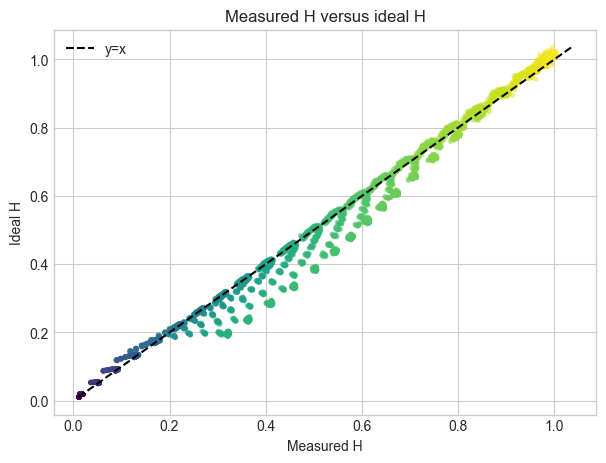

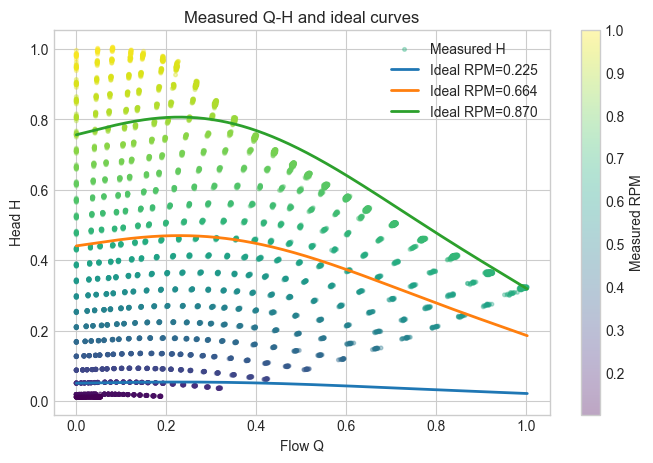

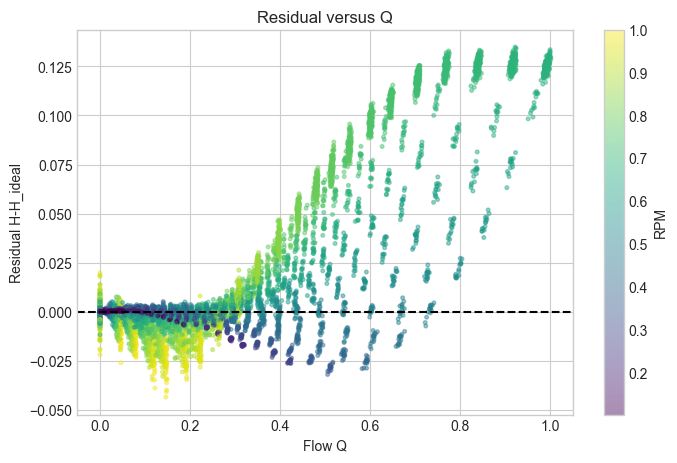

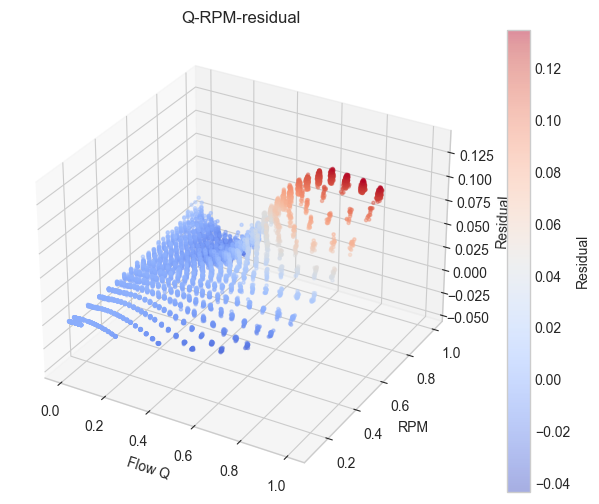

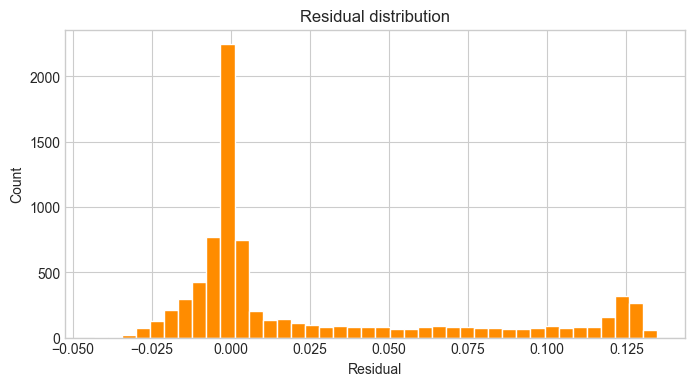

In [4]:
def pump_model_QH(Q, rpm):
    QH_coeff = [-0.580818, 1.65095, -1.4245, 0.105362, 0.104778, 0.249879]
    nref = 0.5
    QH_func = np.poly1d(QH_coeff)
    H_ideal = QH_func(Q) * (rpm / nref) ** 2
    return H_ideal

pump_df["H_ideal"] = pump_model_QH(pump_df["flow"].to_numpy(), pump_df["rpm"].to_numpy())
pump_df["residual"] = pump_df["head"] - pump_df["H_ideal"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pump_df["head"], pump_df.H_ideal, c=pump_df.rpm, s=7, alpha=.45, cmap="viridis")
lims = [pump_df[["head", "H_ideal"]].min().min(), pump_df[["head", "H_ideal"]].max().max()]
ax.plot(lims, lims, "k--", label="y=x")
ax.set(title="Measured H versus ideal H", xlabel="Measured H", ylabel="Ideal H"); ax.legend(); plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(pump_df.flow, pump_df["head"], c=pump_df.rpm, s=7, alpha=.35, label="Measured H", cmap="viridis")
q_grid = np.linspace(pump_df.flow.min(), pump_df.flow.max(), 300)
for rpm_value in np.quantile(pump_df.rpm, [0.1, .5, .9]):
    ax.plot(q_grid, pump_model_QH(q_grid, rpm_value), linewidth=2, label=f"Ideal RPM={rpm_value:.3f}")
ax.set(title="Measured Q-H and ideal curves", xlabel="Flow Q", ylabel="Head H"); ax.legend(); fig.colorbar(sc, ax=ax, label="Measured RPM"); plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(pump_df.flow, pump_df.residual, c=pump_df.rpm, s=7, alpha=.45, cmap="viridis")
ax.axhline(0, color="black", linestyle="--"); ax.set(title="Residual versus Q", xlabel="Flow Q", ylabel="Residual H-H_ideal"); fig.colorbar(sc, ax=ax, label="RPM"); plt.show()

fig = plt.figure(figsize=(9, 6)); ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(pump_df.flow, pump_df.rpm, pump_df.residual, c=pump_df.residual, s=5, alpha=.45, cmap="coolwarm")
ax.set(title="Q-RPM-residual", xlabel="Flow Q", ylabel="RPM", zlabel="Residual"); fig.colorbar(sc, ax=ax, label="Residual"); plt.show()

plt.figure(figsize=(8, 4)); plt.hist(pump_df.residual, bins=40, color="darkorange", edgecolor="white"); plt.title("Residual distribution"); plt.xlabel("Residual"); plt.ylabel("Count"); plt.show()

**Result interpretation.** The ideal model's error reflects performance when only the physical prior is used. If the residual still shows structural trends, low-order functions of Q and RPM may further correct the baseline. The evaluation function below is also called separately on the test set to avoid reporting results only on the complete dataset.

In [5]:
def regression_metrics(y_true, y_pred, epsilon=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    abs_pct = np.abs(y_pred - y_true) / np.maximum(np.abs(y_true), epsilon) * 100.0
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": np.mean(abs_pct),
        "median_abs_pct": np.median(abs_pct),
        "p95_abs_pct": np.percentile(abs_pct, 95),
        "max_abs_pct": np.max(abs_pct),
        "within_5_pct": np.mean(abs_pct <= 5.0) * 100.0,
        "R2": r2_score(y_true, y_pred),
        "min_abs_true": np.min(np.abs(y_true)),
    }

ideal_full_metrics = regression_metrics(pump_df["head"], pump_df.H_ideal)
pd.Series(ideal_full_metrics, name="Ideal/full data")

MAE                0.030998
RMSE               0.052494
MAPE               8.030524
median_abs_pct     2.375835
p95_abs_pct       33.984018
max_abs_pct       51.169840
within_5_pct      62.613636
R2                 0.961313
min_abs_true       0.011151
Name: Ideal/full data, dtype: float64

# 7. Data Splitting Without Leakage

The main experiment splits by complete `pump_id`: training pumps 1-11, validation pumps 12-13, and test pumps 14-15. Similar measurements from the same pump therefore do not appear in both train and test. The scaler is also fitted only on the training data. Even though the values appear normalized, a training-only scaler is still used so the workflow also applies to unnormalized data.

In [6]:
train_pumps = list(range(1, 12))
val_pumps = [12, 13]
test_pumps = [14, 15]
assert not (set(train_pumps) & set(val_pumps) or set(train_pumps) & set(test_pumps) or set(val_pumps) & set(test_pumps))

train_df = pump_df[pump_df.pump_id.isin(train_pumps)].copy()
val_df = pump_df[pump_df.pump_id.isin(val_pumps)].copy()
test_df = pump_df[pump_df.pump_id.isin(test_pumps)].copy()
print("Training pumps:", train_pumps, "rows:", len(train_df))
print("Validation pumps:", val_pumps, "rows:", len(val_df))
print("Test pumps:", test_pumps, "rows:", len(test_df))

FEATURES = ["flow", "rpm"]
TARGET = "residual"
input_scaler = StandardScaler().fit(train_df[FEATURES])
X_train = input_scaler.transform(train_df[FEATURES])
X_val = input_scaler.transform(val_df[FEATURES])
X_test = input_scaler.transform(test_df[FEATURES])
y_train = train_df[TARGET].to_numpy(dtype=np.float32).reshape(-1, 1)
y_val = val_df[TARGET].to_numpy(dtype=np.float32).reshape(-1, 1)
y_test = test_df[TARGET].to_numpy(dtype=np.float32).reshape(-1, 1)
print("Scaler fitted only on training rows.")

Training pumps: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] rows: 5808
Validation pumps: [12, 13] rows: 1056
Test pumps: [14, 15] rows: 1056
Scaler fitted only on training rows.


**Split result.** The test pumps are completely isolated from training and model selection. The target is the residual rather than H directly, so the final output is always `H_ideal + predicted_residual`.

# 8. Polynomial Residual Baseline

A two-dimensional third-order polynomial residual model is implemented following the instructor example. The feature order is explicit: `1,Q,n,Q²,n²,Qn,Q³,n³,Qn²,nQ²`, where `n` denotes RPM. Linear regression is fitted only on the training set, then evaluated on validation and test sets.

train {'MAE': 0.00334, 'RMSE': 0.004645, 'MAPE': 1.181856, 'median_abs_pct': 0.781989, 'p95_abs_pct': 3.455556, 'max_abs_pct': 17.064201, 'within_5_pct': 97.710055, 'R2': 0.999697, 'min_abs_true': 0.011173}
validation {'MAE': 0.003102, 'RMSE': 0.004305, 'MAPE': 1.145505, 'median_abs_pct': 0.733617, 'p95_abs_pct': 3.24701, 'max_abs_pct': 15.618252, 'within_5_pct': 98.484848, 'R2': 0.99974, 'min_abs_true': 0.011254}
test {'MAE': 0.003559, 'RMSE': 0.004883, 'MAPE': 1.243734, 'median_abs_pct': 0.805405, 'p95_abs_pct': 3.50009, 'max_abs_pct': 18.933116, 'within_5_pct': 97.916667, 'R2': 0.999662, 'min_abs_true': 0.011151}


/Users/memo/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/memo/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/memo/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/memo/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/memo/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/memo/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: i

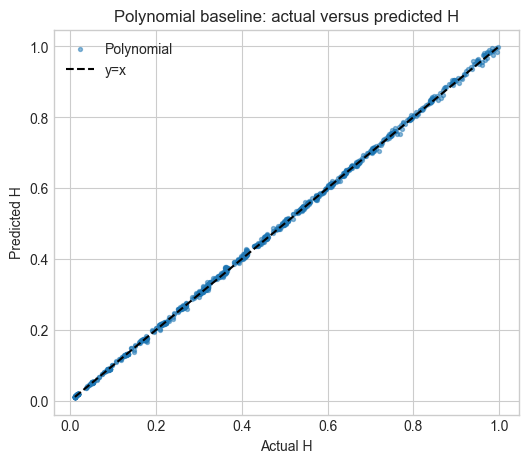

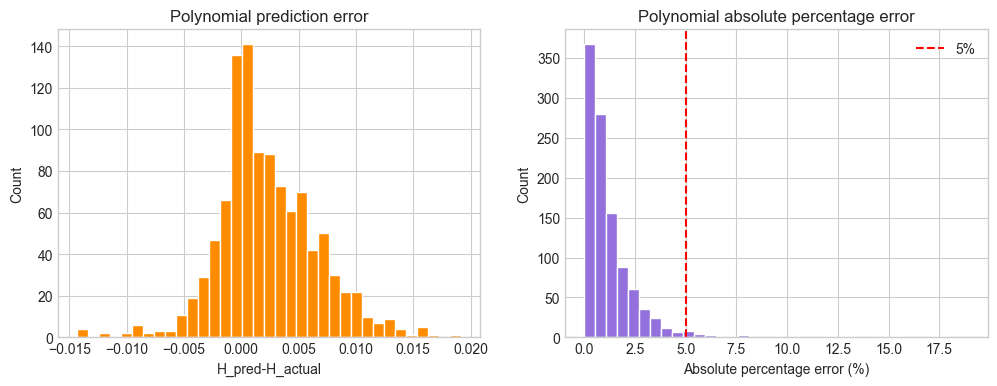

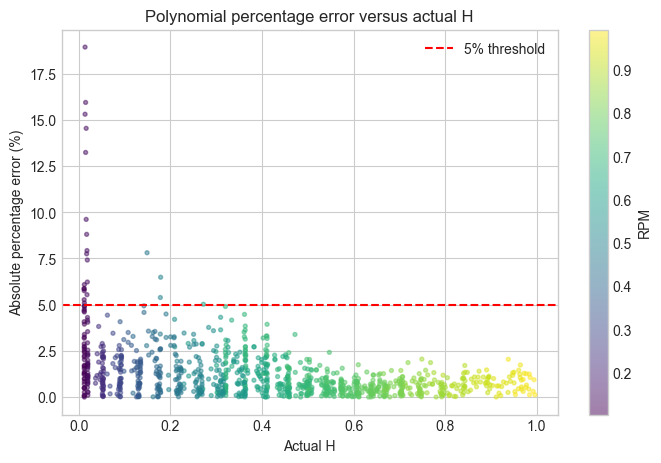

/Users/memo/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/memo/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/memo/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/memo/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/memo/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/memo/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: i

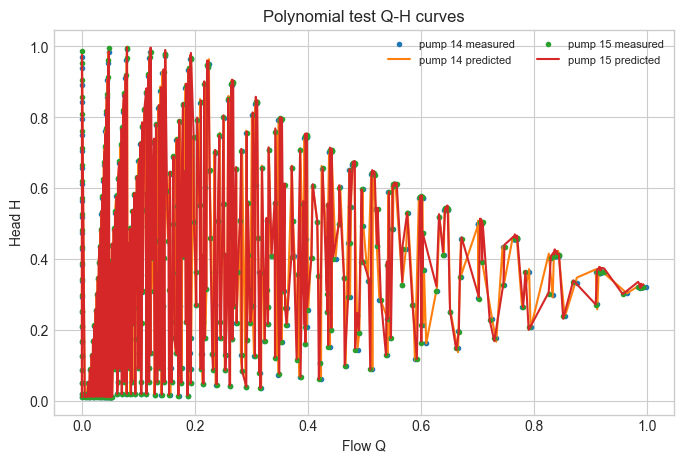

In [7]:
def polynomial_features_q_rpm(frame):
    q = np.asarray(frame["flow"], dtype=float)
    n = np.asarray(frame["rpm"], dtype=float)
    return np.column_stack([np.ones_like(q), q, n, q**2, n**2, q*n, q**3, n**3, q*n**2, n*q**2])

poly_model = LinearRegression(fit_intercept=False)
poly_model.fit(polynomial_features_q_rpm(train_df), y_train.ravel())

def evaluate_predictions(frame, residual_prediction):
    h_ideal = frame["H_ideal"].to_numpy()
    h_pred = h_ideal + np.asarray(residual_prediction).reshape(-1)
    return h_pred, regression_metrics(frame["head"].to_numpy(), h_pred)

poly_predictions = {}
for name, frame in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    h_pred, metrics = evaluate_predictions(frame, poly_model.predict(polynomial_features_q_rpm(frame)))
    poly_predictions[name] = h_pred
    print(name, pd.Series(metrics).round(6).to_dict())

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(test_df["head"], poly_predictions["test"], s=8, alpha=.5, label="Polynomial")
lims = [test_df["head"].min(), test_df["head"].max()]; ax.plot(lims, lims, "k--", label="y=x")
ax.set(title="Polynomial baseline: actual versus predicted H", xlabel="Actual H", ylabel="Predicted H"); ax.legend(); plt.show()

poly_pct = np.abs(poly_predictions["test"] - test_df["head"]) / np.maximum(np.abs(test_df["head"]), 1e-8) * 100
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(poly_predictions["test"] - test_df["head"], bins=35, color="darkorange", edgecolor="white"); axes[0].set(title="Polynomial prediction error", xlabel="H_pred-H_actual", ylabel="Count")
axes[1].hist(poly_pct, bins=35, color="mediumpurple", edgecolor="white"); axes[1].set(title="Polynomial absolute percentage error", xlabel="Absolute percentage error (%)", ylabel="Count"); axes[1].axvline(5, color="red", linestyle="--", label="5%"); axes[1].legend(); plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(test_df["head"], poly_pct, c=test_df.rpm, s=8, alpha=.5, cmap="viridis")
ax.axhline(5, color="red", linestyle="--", label="5% threshold"); ax.set(title="Polynomial percentage error versus actual H", xlabel="Actual H", ylabel="Absolute percentage error (%)"); fig.colorbar(sc, ax=ax, label="RPM"); ax.legend(); plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for pump_id, group in test_df.groupby("pump_id"):
    order = np.argsort(group.flow.to_numpy())
    pred = poly_model.predict(polynomial_features_q_rpm(group)) + group.H_ideal.to_numpy()
    ax.plot(group.flow.to_numpy()[order], group["head"].to_numpy()[order], "o", ms=3, label=f"pump {pump_id} measured")
    ax.plot(group.flow.to_numpy()[order], pred[order], "-", label=f"pump {pump_id} predicted")
ax.set(title="Polynomial test Q-H curves", xlabel="Flow Q", ylabel="Head H"); ax.legend(fontsize=8, ncol=2); plt.show()

**Baseline interpretation.** The polynomial model learns only systematic corrections to the ideal model; it does not replace the physical model directly. Validation metrics are used to observe generalization, while test metrics are reserved for the unified final evaluation to avoid tuning on the test set.

# 9. Lightweight Neural Network Residual Model

The network takes two scaled features as input and has the structure `2 → 16 → 16 → 1`. It learns the residual using MSELoss and Adam; training and validation loss are recorded for each epoch, and the weights with the lowest validation loss are saved. Traditional classification accuracy is not applicable to this regression task; the 5% criterion is calculated separately.

epoch=  1, train_loss=0.00664624, val_loss=0.000485556
epoch= 50, train_loss=1.732e-05, val_loss=1.46651e-05
epoch=100, train_loss=1.57689e-05, val_loss=1.1795e-05
epoch=150, train_loss=1.73151e-05, val_loss=1.14402e-05
epoch=200, train_loss=1.54946e-05, val_loss=1.61711e-05
epoch=250, train_loss=1.48138e-05, val_loss=1.20195e-05
Best epoch: 192, best validation loss: 1.07335e-05


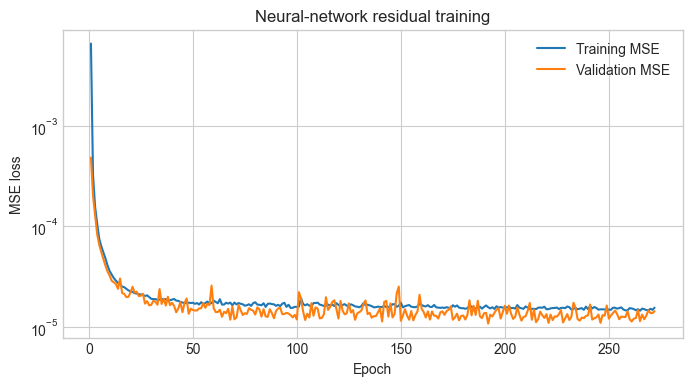

In [8]:
class ResidualNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 16), nn.ReLU(),
            nn.Linear(16, 16), nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.network(x)

train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32)), batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(SEED))
val_x = torch.tensor(X_val, dtype=torch.float32); val_y = torch.tensor(y_val, dtype=torch.float32)
model = ResidualNet().to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
best_state = None; best_val = float("inf"); best_epoch = 0; patience = 80; wait = 0
history = []
for epoch in range(1, 601):
    model.train(); train_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad(); loss = criterion(model(xb), yb); loss.backward(); optimizer.step(); train_losses.append(loss.item())
    model.eval()
    with torch.no_grad(): val_loss = criterion(model(val_x), val_y).item()
    train_loss = float(np.mean(train_losses)); history.append((epoch, train_loss, val_loss))
    if val_loss < best_val - 1e-10:
        best_val, best_epoch, wait = val_loss, epoch, 0; best_state = copy.deepcopy(model.state_dict())
    else:
        wait += 1
    if epoch == 1 or epoch % 50 == 0:
        print(f"epoch={epoch:3d}, train_loss={train_loss:.6g}, val_loss={val_loss:.6g}")
    if wait >= patience: break
model.load_state_dict(best_state)
history_df = pd.DataFrame(history, columns=["epoch", "train_loss", "val_loss"])
print(f"Best epoch: {best_epoch}, best validation loss: {best_val:.6g}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_df.epoch, history_df.train_loss, label="Training MSE")
ax.plot(history_df.epoch, history_df.val_loss, label="Validation MSE")
ax.set(yscale="log", title="Neural-network residual training", xlabel="Epoch", ylabel="MSE loss"); ax.legend(); plt.show()

**Training result interpretation.** The best checkpoint is selected by validation loss rather than using the final epoch. If training loss continues to decrease while validation loss increases, this indicates overfitting; early stopping can limit this behavior.

# 10. Test-Set Evaluation

The trained best weights are now loaded, and the final comparison is performed for the first time on the independent test set. Percentage error uses `max(abs(H_actual), epsilon)` as the denominator; this metric is unstable when H is close to zero, so MAE and RMSE are also reported, together with the minimum H in the test set.

,MAE,RMSE,MAPE,median_abs_pct,p95_abs_pct,max_abs_pct,within_5_pct,R2,min_abs_true
Ideal model,0.030442,0.050979,7.925280,2.435215,33.621819,51.169840,63.352273,0.963204,0.011151
Polynomial residual model,0.003559,0.004883,1.243734,0.805405,3.500090,18.933116,97.916667,0.999662,0.011151
Neural-network residual model,0.003034,0.004206,1.126245,0.715244,4.336398,11.671461,95.833333,0.999750,0.011151


Test set minimum absolute actual H: 0.011151223229207


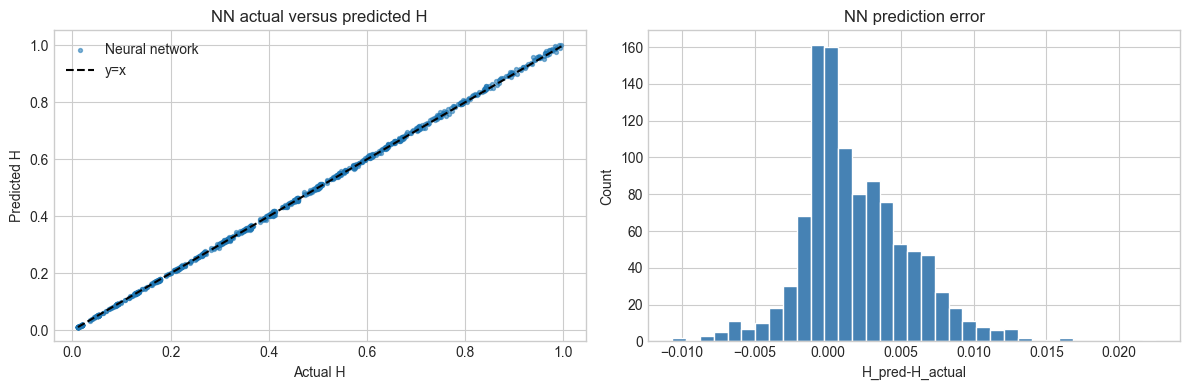

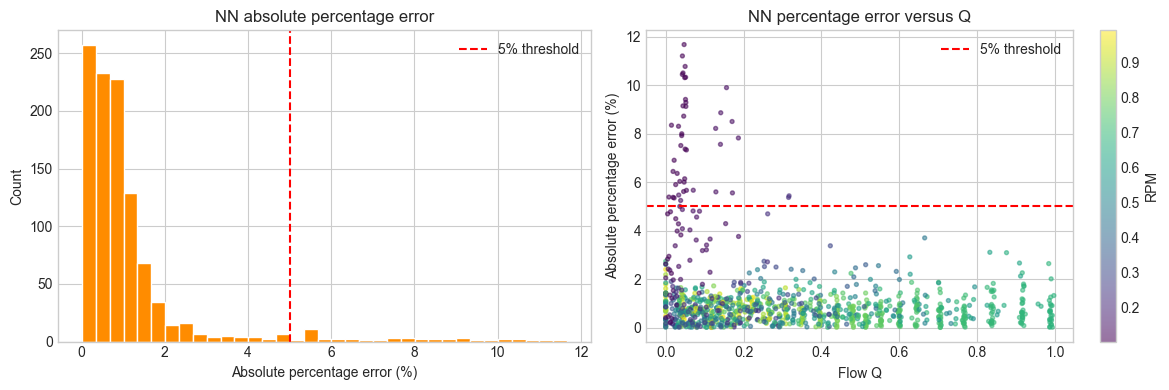

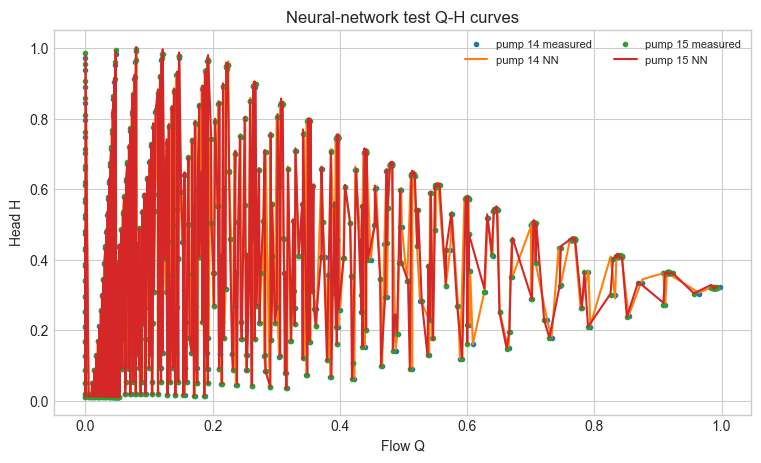

,pump_id,flow,rpm,head,prediction_nn,absolute_percentage_error
7903,15,0.047297,0.103701,0.011731,0.010362,11.671461
7378,14,0.042894,0.103988,0.011769,0.010451,11.200976
7901,15,0.049921,0.104153,0.011712,0.010451,10.768811
7377,14,0.044494,0.104400,0.011773,0.010537,10.499898
7906,15,0.042738,0.104276,0.011743,0.010518,10.437978
7372,14,0.051116,0.104605,0.011763,0.010549,10.322442
7374,14,0.048838,0.104564,0.011764,0.010551,10.307554
7350,14,0.156146,0.134868,0.015719,0.014164,9.893779
7900,15,0.050844,0.104893,0.011719,0.010616,9.408462
7371,14,0.051788,0.105058,0.011739,0.010649,9.283056


Mean percentage error <= 5%? True
Maximum error for all test points <= 5%? False
Percentage of test points with error <= 5%: 95.83%


In [9]:
model.eval()
with torch.no_grad():
    residual_nn_test = model(torch.tensor(X_test, dtype=torch.float32)).cpu().numpy().ravel()
h_pred_nn = test_df.H_ideal.to_numpy() + residual_nn_test

ideal_test_pred = test_df.H_ideal.to_numpy()
model_table = pd.DataFrame({
    "Ideal model": regression_metrics(test_df["head"], ideal_test_pred),
    "Polynomial residual model": regression_metrics(test_df["head"], poly_predictions["test"]),
    "Neural-network residual model": regression_metrics(test_df["head"], h_pred_nn),
}).T
display(model_table.round(6))
print("Test set minimum absolute actual H:", float(np.min(np.abs(test_df["head"]))))

errors = h_pred_nn - test_df["head"].to_numpy()
abs_pct = np.abs(errors) / np.maximum(np.abs(test_df["head"].to_numpy()), 1e-8) * 100
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(test_df["head"], h_pred_nn, s=8, alpha=.55, label="Neural network")
lims = [test_df["head"].min(), test_df["head"].max()]; axes[0].plot(lims, lims, "k--", label="y=x")
axes[0].set(title="NN actual versus predicted H", xlabel="Actual H", ylabel="Predicted H"); axes[0].legend()
axes[1].hist(errors, bins=35, color="steelblue", edgecolor="white"); axes[1].set(title="NN prediction error", xlabel="H_pred-H_actual", ylabel="Count")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(abs_pct, bins=35, color="darkorange", edgecolor="white"); axes[0].axvline(5, color="red", linestyle="--", label="5% threshold"); axes[0].set(title="NN absolute percentage error", xlabel="Absolute percentage error (%)", ylabel="Count"); axes[0].legend()
sc = axes[1].scatter(test_df.flow, abs_pct, c=test_df.rpm, s=8, alpha=.55, cmap="viridis"); axes[1].axhline(5, color="red", linestyle="--", label="5% threshold"); axes[1].set(title="NN percentage error versus Q", xlabel="Flow Q", ylabel="Absolute percentage error (%)"); axes[1].legend(); fig.colorbar(sc, ax=axes[1], label="RPM")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
for pump_id, group in test_df.groupby("pump_id"):
    positions = test_df.index.get_indexer(group.index)
    order = np.argsort(group.flow.to_numpy())
    ax.plot(group.flow.to_numpy()[order], group["head"].to_numpy()[order], "o", ms=3, label=f"pump {pump_id} measured")
    ax.plot(group.flow.to_numpy()[order], h_pred_nn[positions][order], "-", label=f"pump {pump_id} NN")
ax.set(title="Neural-network test Q-H curves", xlabel="Flow Q", ylabel="Head H"); ax.legend(fontsize=8, ncol=2); plt.show()

worst = test_df[["pump_id", "flow", "rpm", "head"]].copy()
worst["prediction_nn"] = h_pred_nn; worst["absolute_percentage_error"] = abs_pct
display(worst.sort_values("absolute_percentage_error", ascending=False).head(10))

final_metrics = model_table.loc["Neural-network residual model"]
print(f"Mean percentage error <= 5%? {final_metrics['MAPE'] <= 5.0}")
print(f"Maximum error for all test points <= 5%? {final_metrics['max_abs_pct'] <= 5.0}")
print(f"Percentage of test points with error <= 5%: {final_metrics['within_5_pct']:.2f}%")

**5% assessment.** The mean MAPE, maximum error, and proportion of samples within 5% must be considered separately. A mean value below 5% does not mean that every test point is below 5%; the final conclusion is based on the actual test output here.

# 11. Embedded-Hardware Considerations

The parameter count and float32 parameter memory are estimated below. Real deployment may also require quantization, C/C++ conversion, and hardware latency testing; this Notebook does not claim that a real embedded deployment has already been completed.

In [10]:
parameter_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
parameter_memory_bytes = parameter_count * 4
print("Network:", model)
print("Trainable parameter count:", parameter_count)
print("Approximate float32 parameter memory (bytes):", parameter_memory_bytes)
print("Approximate float32 parameter memory (KiB):", parameter_memory_bytes / 1024)
print("Saved PyTorch file size is reported after saving in the next section.")

Network: ResidualNet(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)
Trainable parameter count: 337
Approximate float32 parameter memory (bytes): 1348
Approximate float32 parameter memory (KiB): 1.31640625
Saved PyTorch file size is reported after saving in the next section.


The small network accepts only two inputs and outputs one residual, so its matrix multiplications are modest and suitable for low-memory inference. Deployment must also preserve the scaler parameters, ideal-model coefficients, and polynomial/NN configuration; the memory for these items should be included in the complete model package.

# 12. Save the Complete Model Package

Create the project-relative `saved_models/` path and save the best weights, scaler, ideal-model parameters, feature names, and metadata.

In [11]:
saved_dir = Path("saved_models")
saved_dir.mkdir(exist_ok=True)
model_path = saved_dir / "pump_residual_model.pth"
input_scaler_path = saved_dir / "input_scaler.joblib"
target_scaler_path = saved_dir / "target_scaler.joblib"
metadata_path = saved_dir / "model_metadata.json"

torch.save(model.state_dict(), model_path)
joblib.dump(input_scaler, input_scaler_path)
# This experiment does not apply target scaling to the residual; save None as explicit metadata.
joblib.dump(None, target_scaler_path)
metadata = {
    "model_class": "ResidualNet",
    "architecture": ["Linear(2,16)", "ReLU", "Linear(16,16)", "ReLU", "Linear(16,1)"],
    "features": FEATURES,
    "target": TARGET,
    "ideal_coefficients": [-0.580818, 1.65095, -1.4245, 0.105362, 0.104778, 0.249879],
    "nref": 0.5,
    "seed": SEED,
    "train_pumps": train_pumps, "validation_pumps": val_pumps, "test_pumps": test_pumps,
    "target_scaling": False
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
for path in [model_path, input_scaler_path, target_scaler_path, metadata_path]:
    print(path, path.stat().st_size, "bytes")

saved_models/pump_residual_model.pth 4581 bytes
saved_models/input_scaler.joblib 919 bytes
saved_models/target_scaler.joblib 4 bytes
saved_models/model_metadata.json 563 bytes


The saved results include the network weights, input scaler, target-scaler placeholder object, and metadata. Relative project paths allow the Notebook to be moved and run within the project folder.

# 13. Reload and Verify

This section simulates an independent inference workflow: create a new model object, load the state dictionary, scaler, and metadata from disk, and then predict the same test samples. If the predictions differ before and after loading, an error is raised immediately.

In [12]:
loaded_metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
loaded_scaler = joblib.load(input_scaler_path)
_ = joblib.load(target_scaler_path)
loaded_model = ResidualNet().to(DEVICE)
loaded_model.load_state_dict(torch.load(model_path, map_location=DEVICE, weights_only=True))
loaded_model.eval()

X_reload = loaded_scaler.transform(test_df[loaded_metadata["features"]])
with torch.no_grad():
    residual_reload = loaded_model(torch.tensor(X_reload[:8], dtype=torch.float32)).cpu().numpy().ravel()
h_reload = test_df.H_ideal.to_numpy()[:8] + residual_reload
h_before = h_pred_nn[:8]
if not np.allclose(h_before, h_reload, rtol=1e-6, atol=1e-7):
    raise RuntimeError("Predictions after reloading from disk do not match the predictions before saving.")

verification = test_df[["flow", "rpm", "head"]].iloc[:8].copy()
verification.columns = ["Q", "RPM", "Actual H"]
verification["Prediction before save"] = h_before
verification["Prediction after reload"] = h_reload
verification["Percentage error"] = np.abs(h_reload - verification["Actual H"].to_numpy()) / np.maximum(np.abs(verification["Actual H"].to_numpy()), 1e-8) * 100
display(verification)
print("Reload verification passed: np.allclose=True")

,Q,RPM,Actual H,Prediction before save,Prediction after reload,Percentage error
6864,0.986316,0.674836,0.319093,0.320088,0.320088,0.311550
6865,0.914029,0.686678,0.360855,0.363155,0.363155,0.637404
6866,0.836730,0.695271,0.408100,0.407477,0.407477,0.152706
6867,0.763742,0.710444,0.455123,0.458649,0.458649,0.774750
6868,0.703408,0.723808,0.497574,0.500935,0.500935,0.675664
6869,0.641039,0.736513,0.538948,0.539451,0.539451,0.093304
6870,0.600062,0.754317,0.572098,0.577309,0.577309,0.910926
6871,0.551930,0.763734,0.606533,0.604805,0.604805,0.284854


Reload verification passed: np.allclose=True


# 14. Optional Single-Pump Calibration Experiment

This additional experiment does not contaminate the main test-set results. Test pump 14 is selected; its first five measurements estimate a residual offset, and the remaining points show the change before and after adaptation. This represents adapting to a specific pump with very little data, rather than producing a new fair global test result.

In [13]:
calibration_pump = 14
calibration_group = test_df[test_df.pump_id == calibration_pump].copy()
if len(calibration_group) >= 6:
    calibration_points = calibration_group.iloc[:5]
    evaluation_points = calibration_group.iloc[5:]
    base_residual = model(torch.tensor(input_scaler.transform(evaluation_points[FEATURES]), dtype=torch.float32)).detach().numpy().ravel()
    base_pred = evaluation_points.H_ideal.to_numpy() + base_residual
    offset = float(np.mean(calibration_points.residual.to_numpy() - model(torch.tensor(input_scaler.transform(calibration_points[FEATURES]), dtype=torch.float32)).detach().numpy().ravel()))
    calibrated_pred = base_pred + offset
    print("Calibration points:", len(calibration_points), "evaluation points:", len(evaluation_points), "offset:", offset)
    display(pd.DataFrame({"Before calibration": regression_metrics(evaluation_points["head"], base_pred), "After calibration": regression_metrics(evaluation_points["head"], calibrated_pred)}).T.round(6))
else:
    print("Calibration experiment skipped: selected pump has fewer than 6 rows.")

Calibration points: 5 evaluation points: 523 offset: -0.0019118072140244912


,MAE,RMSE,MAPE,median_abs_pct,p95_abs_pct,max_abs_pct,within_5_pct,R2,min_abs_true
Before calibration,0.003280,0.004504,1.170918,0.758270,4.247242,11.200976,95.984704,0.999714,0.011151
After calibration,0.002969,0.003855,2.406922,0.694116,17.883119,27.445145,91.013384,0.999790,0.011151


# 15. Final Conclusion

## Direct answer to the research question

**Can we create a model to predict pump performance within 5% accuracy?**

**Conclusion: partially achieved, and the two definitions of 5% must be distinguished.** On the independent test set, the neural-network residual model produced:

- `MAE = 0.003034`
- `RMSE = 0.004206`
- `MAPE = 1.126%`
- `95th percentile absolute percentage error = 4.336%`
- `maximum absolute percentage error = 11.671%`
- `95.833%` of test samples meet the absolute percentage error criterion of `<= 5%`

Therefore:

- **The mean-error criterion is met**: MAPE is `1.126%`, below `5%`.
- **The maximum-error criterion is not met**: the maximum error is `11.671%`, so it cannot be claimed that every prediction is within `5%`.
- **The precise final statement is: mean prediction accuracy meets the 5% requirement, but the strict pointwise 5% requirement is not met.** This conclusion is not based on retraining or tuning with the test set; the test set is used only for one final evaluation.

## Requirement-by-requirement conclusion

1. **Focus on Q/H only with rpm as the control parameter: satisfied.**\
   The model uses only `Q = flow` and `rpm` as inputs to predict `H = head`; `power` and `efficiency` are not model inputs.

2. **Use `H(Q, rpm)` as the simplification: satisfied.**\
   The model uses the instructor-provided ideal pump model and learns `residual = H_measured - H_ideal`. The final prediction is:
   
   `H_predicted = H_ideal(Q, rpm) + residual_predicted(Q, rpm)`

3. **Should run on embedded hardware: broadly satisfied, with deployment potential.**\
   The neural network is `2 -> 16 -> 16 -> 1`, with approximately `337` trainable parameters, about `1.3 KiB` of float32 parameter memory, and a saved weight file of approximately `4.6 KiB`. Inference requires only two inputs, the scaler, ideal-model computation, and a small network, so computational and memory costs are low. Real embedded deployment still requires quantization, C/C++ or another runtime conversion, and latency testing on actual hardware.

4. **Consider compute and memory limitations: basic experimental requirement satisfied.**\
   The Notebook reports the network structure, parameter count, float32 parameter memory, and model file size, and saves the scaler and ideal-model metadata. Complete deployment must also include the scaler parameters and ideal-model coefficients in the firmware or model package.

5. **Extra: calibrate to a specific pump using 3-5 data points: implemented.**\
   The optional experiment uses `5` calibration points from pump 14 to estimate a residual offset and evaluates the remaining `523` points. In this experiment, calibration reduced MAE from `0.003280` to `0.002969`, but increased MAPE from `1.171%` to `2.407%` and maximum error from `11.201%` to `27.445%`. Thus, the five-point calibration workflow has been verified, but this simple global-offset correction **did not improve every percentage-error metric** and should not be reported as a generally effective improvement.

## Final statement

This experiment builds a lightweight `H(Q, rpm)` pump digital twin. It reaches the 5% target in terms of mean error, and its model size is suitable for further consideration of embedded deployment. However, a few low-head test samples still have relative errors above 5%, so the strict goal that every test point remain within 5% has not been achieved. Future work can incorporate quantization, C conversation and actual hardware testings to ensure actual deployment.